# Parameter sweeps

Vary one knob, plot a fan of SEDs — the cheapest way to build physical intuition.
Because tengri's model is pure JAX, sweeps can be batched through `vmap` and run
in a single compiled call. This notebook covers:

1. 1-D sweeps with `sweep_parameter`.
2. Prior fans via `sample_sfh_prior`.
3. Photometric setup with `Instrument`.
4. 2-D photometric grids via `predict_photometry_batch` and `jax.vmap`.

In [ ]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import sys

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import tengri
from tengri import (
    Fixed,
    Instrument,
    Parameters,
    SEDModel,
    Uniform,
)
from tengri.analysis.plotting import SWEEP_CMAPS, setup_style, sweep_parameter
from tengri.components.stellar.sfh import sample_sfh_prior

setup_style()
print(f"tengri {tengri.__version__}")

tengri 0.1.0


In [ ]:
ssp = tengri.load_ssp("ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0", download=True)

src/tengri/components/stellar/sps/dsps_wrapper.py:298: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only — adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))


## 1-D sweep with `sweep_parameter`

Build a fixed star-forming galaxy and vary one knob. A sweep holds all other
parameters at their fixed values, so the fan understates the real degeneracy
— a full fit frees other parameters and expands the contours.

<string>:24: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) cmr10.
Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.
<string>:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


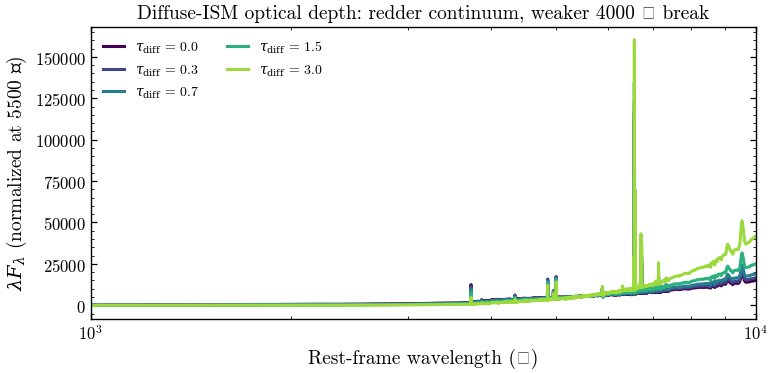

In [ ]:
spec_sf = Parameters(
    sfh_tsnorm_log_total_mass=Fixed(10.0),
    sfh_tsnorm_peak_lbt_gyr=Fixed(2.0),
    sfh_tsnorm_width_gyr=Fixed(1.5),
    sfh_tsnorm_skew=Fixed(0.2),
    sfh_tsnorm_trunc=Fixed(3.0),
    met_logzsol=Fixed(-0.3),
    dust_tau_bc=Fixed(0.5),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
)
model_sf = SEDModel(spec_sf, ssp)

fig, ax = sweep_parameter(
    model_sf,
    "dust_tau_diff",
    [0.0, 0.3, 0.7, 1.5, 3.0],
    cmap=SWEEP_CMAPS["dust"],
    label_fmt=r"$\tau_{{\rm diff}}$ = {:.1f}",
    wave_range=(1000, 10000),
)
ax.set_title("Diffuse-ISM optical depth: redder continuum, weaker 4000 Å break")
fig.tight_layout()
plt.show()

## A prior fan via `sample_sfh_prior`

What range of behavior does the prior actually allow? `sample_sfh_prior` draws
from a registered SFH family's default prior and returns the SFR curves directly.

<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


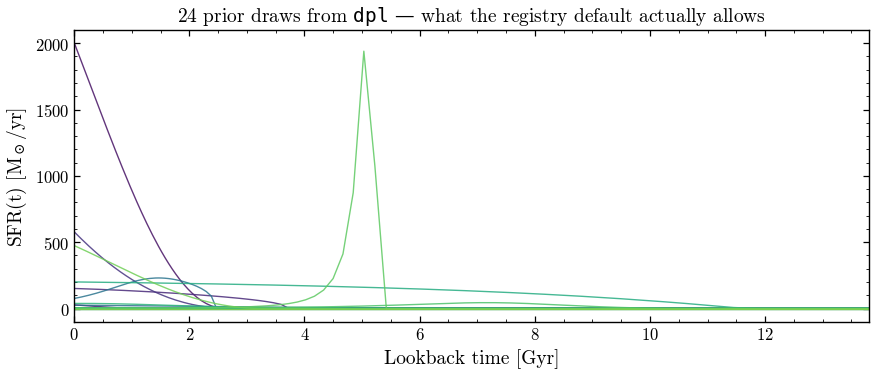

In [ ]:
age_grid_yr, curves = sample_sfh_prior(
    "dpl",  # double-power-law SFH (Carnall+2018)
    jax.random.PRNGKey(0),
    n=24,
)

fig, ax = plt.subplots(figsize=(9, 4))
age_gyr = np.asarray(age_grid_yr) / 1e9
viridis = plt.get_cmap("viridis")
for i, c in enumerate(np.asarray(curves)):
    ax.plot(age_gyr, c, color=viridis(0.05 + 0.8 * i / len(curves)), lw=1.0, alpha=0.85)
ax.set_xlim(0, 13.8)
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"SFR(t) [M$_\odot$/yr]")
ax.set_title(r"24 prior draws from $\tt{dpl}$ — what the registry default actually allows")
fig.tight_layout()
plt.show()

Override one prior to narrow the fan:

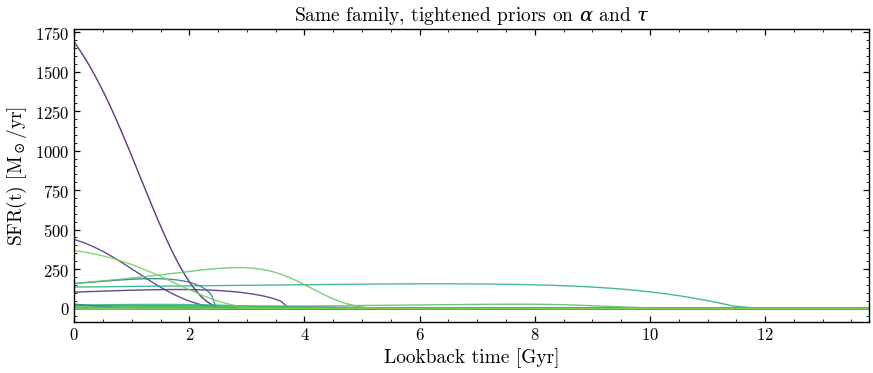

In [ ]:
_, narrow = sample_sfh_prior(
    "dpl",
    jax.random.PRNGKey(0),
    n=24,
    sfh_dpl_alpha=Uniform(0.5, 1.5),  # default is Uniform(0.1, 5.0)
    sfh_dpl_tau_gyr=Uniform(2.0, 4.0),  # default is Uniform(0.1, 12.0)
)

fig, ax = plt.subplots(figsize=(9, 4))
for i, c in enumerate(np.asarray(narrow)):
    ax.plot(age_gyr, c, color=viridis(0.05 + 0.8 * i / len(narrow)), lw=1.0, alpha=0.85)
ax.set_xlim(0, 13.8)
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"SFR(t) [M$_\odot$/yr]")
ax.set_title(r"Same family, tightened priors on $\alpha$ and $\tau$")
fig.tight_layout()
plt.show()

## Photometric setup with `Instrument`

The `Instrument` registry bundles canonical filter sets:

In [ ]:
for inst_factory in (Instrument.SDSS, Instrument.JWST_NIRCam, Instrument.WISE):
    inst = inst_factory()
    print(f"  {inst.name:14s}  {inst.photometry.n_filters} bands  {inst.description}")

  SDSS            5 bands  SDSS ugriz; the canonical low-z optical photometric set.
  JWST_NIRCam     8 bands  JWST NIRCam wide bands (F070W–F444W); the canonical JADES/CEERS set.
  WISE            4 bands  WISE W1–W4 mid-IR.


## A 2-D photometric grid via `predict_photometry_batch`

For multi-axis sweeps, use `model.predict_photometry_batch`, a `jax.vmap` of
the per-galaxy predictor. We sweep `met_logzsol` against `dust_tau_diff` for
an SDSS model and track how the *color* `g - r` moves.

<string>:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


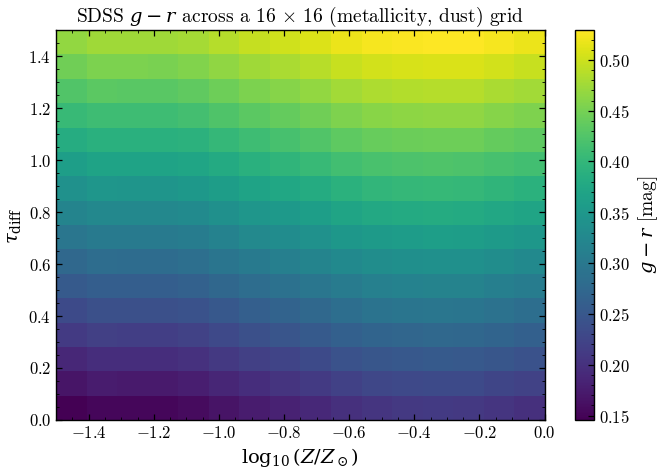

In [ ]:
spec_grid = Parameters(
    sfh_tsnorm_log_total_mass=Fixed(10.0),
    sfh_tsnorm_peak_lbt_gyr=Fixed(2.0),
    sfh_tsnorm_width_gyr=Fixed(1.5),
    sfh_tsnorm_skew=Fixed(0.2),
    sfh_tsnorm_trunc=Fixed(3.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Fixed(0.5),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.05),
)
inst_sdss = Instrument.SDSS()
model_grid = SEDModel(spec_grid, ssp, observation=inst_sdss.observation())

n_z, n_d = 16, 16
met_axis = jnp.linspace(-1.5, 0.0, n_z)
dust_axis = jnp.linspace(0.0, 1.5, n_d)
mm, dd = jnp.meshgrid(met_axis, dust_axis, indexing="ij")

# Build the batch dict: shape (n_z * n_d,) on the swept keys, broadcast
# the fixed values to match.
base = spec_grid.sample(jax.random.PRNGKey(0))
n_total = n_z * n_d
params_batch = {}
for k, v in base.items():
    v = jnp.asarray(v)
    if k == "met_logzsol":
        params_batch[k] = mm.reshape(-1)
    elif k == "dust_tau_diff":
        params_batch[k] = dd.reshape(-1)
    else:
        params_batch[k] = jnp.broadcast_to(v, (n_total, *v.shape))

flux = model_grid.predict_photometry_batch(params_batch)  # (256, 5) for SDSS
flux = flux.reshape(n_z, n_d, -1)  # (n_z, n_d, n_filters)

i_g = inst_sdss.filter_names.index("sdss_g")
i_r = inst_sdss.filter_names.index("sdss_r")
g_minus_r = -2.5 * (jnp.log10(flux[..., i_g]) - jnp.log10(flux[..., i_r]))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    np.asarray(g_minus_r).T,
    origin="lower",
    aspect="auto",
    extent=(float(met_axis[0]), float(met_axis[-1]), float(dust_axis[0]), float(dust_axis[-1])),
    cmap="viridis",
)
cbar = fig.colorbar(im, ax=ax, label=r"$g - r$ [mag]")
ax.set_xlabel(r"$\log_{10}(Z / Z_\odot)$")
ax.set_ylabel(r"$\tau_{\rm diff}$")
ax.set_title("SDSS $g-r$ across a 16 × 16 (metallicity, dust) grid")
fig.tight_layout()
plt.show()

256 forward evaluations in one compiled `vmap` call. Both axes drive redder
colors; the metallicity–dust degeneracy is why photo-z fits need spectroscopy.

## Sweeping a categorical knob: dust attenuation law

Categorical knobs (dust law, AGN model) also benefit from a "fan" plot.
Here we hold τ_diff fixed and sweep the diffuse-ISM attenuation law.

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.
<string>:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


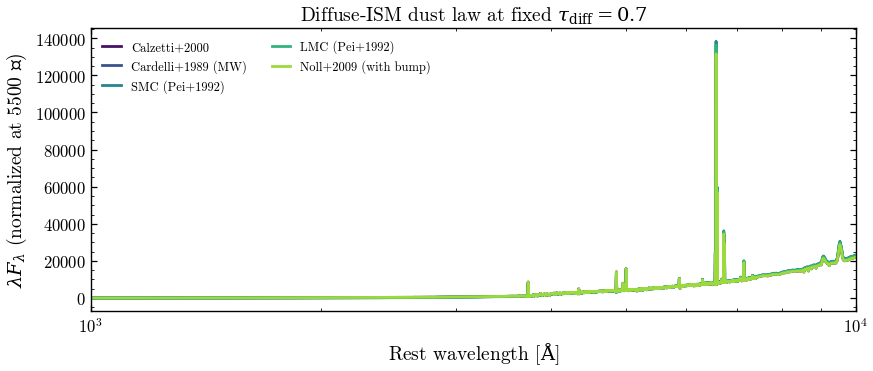

In [ ]:
DUST_LAW_LABELS = {
    "calzetti": "Calzetti+2000",
    "cardelli": "Cardelli+1989 (MW)",
    "smc": "SMC (Pei+1992)",
    "lmc": "LMC (Pei+1992)",
    "noll09": "Noll+2009 (with bump)",
}

fig, ax = plt.subplots(figsize=(9, 4))
viridis = plt.get_cmap("viridis")
for i, (law_name, label) in enumerate(DUST_LAW_LABELS.items()):
    spec_law = Parameters(
        sfh_tsnorm_log_total_mass=Fixed(10.0),
        sfh_tsnorm_peak_lbt_gyr=Fixed(2.0),
        sfh_tsnorm_width_gyr=Fixed(1.5),
        sfh_tsnorm_skew=Fixed(0.2),
        sfh_tsnorm_trunc=Fixed(3.0),
        met_logzsol=Fixed(-0.3),
        dust_tau_bc=Fixed(0.5),
        dust_tau_diff=Fixed(0.7),
        dust_slope=Fixed(-0.7),
        dust_law_diff=law_name,  # <-- the categorical sweep
        redshift=Fixed(0.0),
    )
    model_law = SEDModel(spec_law, ssp)
    pred = model_law.predict(spec_law.sample(jax.random.PRNGKey(0)))
    wave = np.asarray(pred.wave_rest)
    lnu = np.asarray(pred.rest_sed())
    mask = (wave >= 1000) & (wave <= 10000)
    # Normalize at 5500 Å for side-by-side shape comparison.
    inorm = int(np.argmin(np.abs(wave - 5500.0)))
    y = (lnu / lnu[inorm]) * wave
    color = viridis(0.05 + 0.8 * i / max(len(DUST_LAW_LABELS) - 1, 1))
    ax.plot(wave[mask], y[mask], color=color, lw=2.0, label=label)
ax.set_xscale("log")
ax.set_xlim(1000, 10000)
ax.set_xlabel(r"Rest wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"$\lambda F_\lambda$ (normalized at 5500 Å)")
ax.set_title(r"Diffuse-ISM dust law at fixed $\tau_{\rm diff} = 0.7$")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

UV slopes spread by ~1 mag/dex even at the same optical depth — the
2175 Å bump shows up clearly in `noll09`, the SMC curve has the
steepest UV rise, and Calzetti sits where most fits assume it does.

## Photometric tracks across redshift

One galaxy traced across redshifts traces a locus in color-color space
that high-z selection cuts (Lyman-break, BzK, dropouts) live on. Here we
vmap a single SFH/dust truth across z ∈ [0.5, 8] through JWST NIRCam.

<string>:39: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) cmr10.
<string>:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


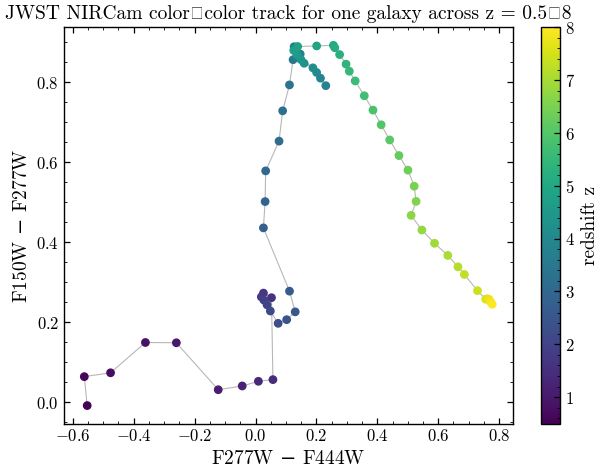

In [ ]:
inst_jwst = Instrument.JWST_NIRCam()
spec_z = Parameters(
    sfh_tsnorm_log_total_mass=Fixed(10.0),
    sfh_tsnorm_peak_lbt_gyr=Fixed(0.3),
    sfh_tsnorm_width_gyr=Fixed(0.2),
    sfh_tsnorm_skew=Fixed(0.0),
    sfh_tsnorm_trunc=Fixed(3.0),
    met_logzsol=Fixed(-0.5),
    dust_tau_bc=Fixed(0.3),
    dust_tau_diff=Fixed(0.2),
    dust_slope=Fixed(-0.7),
    redshift=Uniform(0.5, 8.0),
)
model_z = SEDModel(spec_z, ssp, observation=inst_jwst.observation())

z_grid = jnp.linspace(0.5, 8.0, 64)
base_z = spec_z.sample(jax.random.PRNGKey(0))
batch_z = {
    k: jnp.broadcast_to(jnp.asarray(v), (z_grid.size, *jnp.asarray(v).shape))
    for k, v in base_z.items()
}
batch_z["redshift"] = z_grid

flux_z = model_z.predict_photometry_batch(batch_z)  # (64, 8 NIRCam bands)
i150 = inst_jwst.filter_names.index("jwst_f150w")
i277 = inst_jwst.filter_names.index("jwst_f277w")
i444 = inst_jwst.filter_names.index("jwst_f444w")

c1 = -2.5 * (jnp.log10(flux_z[:, i150]) - jnp.log10(flux_z[:, i277]))  # F150W - F277W
c2 = -2.5 * (jnp.log10(flux_z[:, i277]) - jnp.log10(flux_z[:, i444]))  # F277W - F444W

fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(np.asarray(c2), np.asarray(c1), c=np.asarray(z_grid), cmap="viridis", s=28)
ax.plot(np.asarray(c2), np.asarray(c1), color="0.6", lw=0.8, alpha=0.7, zorder=0)
fig.colorbar(sc, ax=ax, label="redshift z")
ax.set_xlabel(r"F277W $-$ F444W")
ax.set_ylabel(r"F150W $-$ F277W")
ax.set_title("JWST NIRCam color–color track for one galaxy across z = 0.5–8")
fig.tight_layout()
plt.show()

The kink at z ≈ 6 is the Lyman break exiting F150W. The same `vmap` pattern
scales to populations: replace broadcast values with per-galaxy arrays for
thousands of mock galaxies in one compiled call.

## AGN bolometric luminosity sweep

Vary `agn_log_lbol = log10(L_bol / L_sun)` on top of a fixed star-forming host
to see the IR/MIR rise as the AGN turns up.

<string>:28: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) cmr10.
Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.
<string>:28: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) cmr10.
<string>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


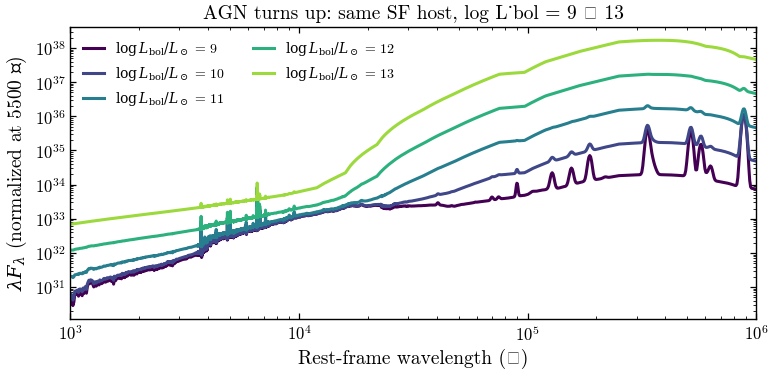

In [ ]:
spec_agn = Parameters(
    sfh_tsnorm_log_total_mass=Fixed(10.0),
    sfh_tsnorm_peak_lbt_gyr=Fixed(2.0),
    sfh_tsnorm_width_gyr=Fixed(1.5),
    sfh_tsnorm_skew=Fixed(0.2),
    sfh_tsnorm_trunc=Fixed(3.0),
    met_logzsol=Fixed(-0.3),
    dust_tau_bc=Fixed(0.5),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    agn_model="multicolor_agn",
    agn_log_lbol=Fixed(10.0),
    redshift=Fixed(0.05),
)
model_agn = SEDModel(spec_agn, ssp)

fig, ax = sweep_parameter(
    model_agn,
    "agn_log_lbol",
    [9.0, 10.0, 11.0, 12.0, 13.0],
    cmap=SWEEP_CMAPS["agn"],
    label_fmt=r"$\log L_{{\rm bol}}/L_\odot$ = {:.0f}",
    wave_range=(1000, 1e6),  # UV through MIR
    log_scale=True,
    normalize_at=None,  # show absolute scaling
)
ax.set_title("AGN turns up: same SF host, log L_bol = 9 → 13")
fig.tight_layout()
plt.show()

Below `log L_bol ≈ 10` the SED is host-dominated; above ~12 the AGN disc
dominates UV–optical and the torus dominates mid-IR. The crossover is where
AGN/SF decompositions are most identifiable — and most degenerate.

## Stochastic SFH: PSD-driven burstiness

Tengri's stochastic SFHs use IFT correlated fields with PSD-governed burstiness.
The two knobs are the PSD amplitude (`σ`, in dex of SFR variability) and
timescale (`τ`, in Myr). At fixed `σ`, varying `τ` spans fast spiky variability
(small `τ`) to slow drift (large `τ`).

<string>:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


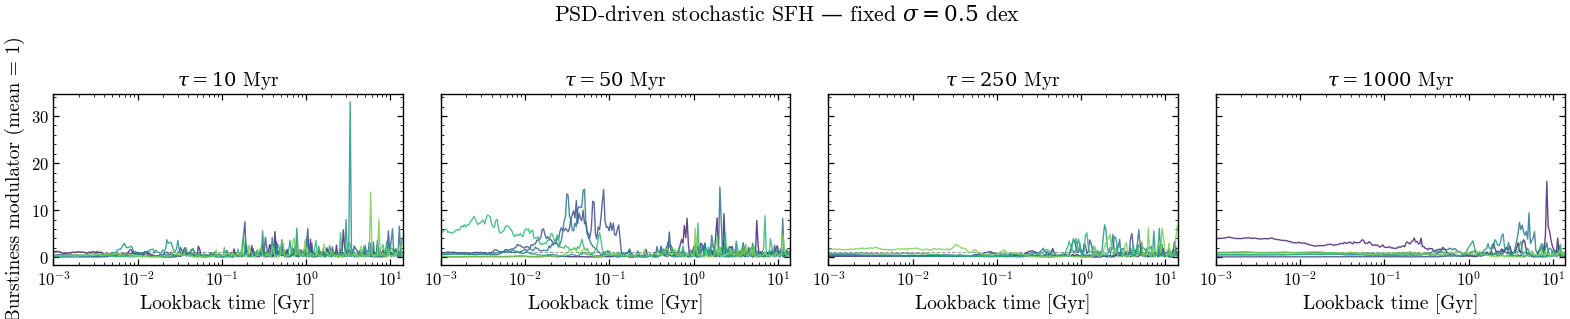

In [ ]:
from tengri.components.stellar.sfh import compute_field_gp
from tengri.components.stellar.sfh.gp_sfh import make_log_age_grid

n_grid = 256
log_age = make_log_age_grid(n_grid=n_grid)
d_log = float(log_age[1] - log_age[0])
age_yr = 10.0 ** np.asarray(log_age)
age_gyr_field = age_yr / 1e9

# Fix sigma; sweep tau through three orders of magnitude.
sigma_dex = 0.5
tau_values_myr = [10.0, 50.0, 250.0, 1000.0]
n_realizations = 6

fig, axes = plt.subplots(
    1, len(tau_values_myr), figsize=(4 * len(tau_values_myr), 3.2), sharey=True
)
for ax, tau_myr in zip(axes, tau_values_myr):
    key = jax.random.PRNGKey(int(tau_myr))
    for r in range(n_realizations):
        xi = jax.random.normal(jax.random.fold_in(key, r), shape=(n_grid,))
        gp_x, k0_half = compute_field_gp(
            xi,
            psd_sigma=sigma_dex,
            psd_tau_yr=tau_myr * 1e6,
            n_grid=n_grid,
            d_log_age=d_log,
        )
        modulator = jnp.exp(gp_x - k0_half)  # mass-conserving lognormal
        ax.plot(
            age_gyr_field,
            np.asarray(modulator),
            lw=1.0,
            alpha=0.85,
            color=viridis(0.1 + 0.7 * r / max(n_realizations - 1, 1)),
        )
    ax.set_xscale("log")
    ax.set_xlim(1e-3, 14)
    ax.axhline(1.0, color="0.6", lw=0.7, ls="--", zorder=0)
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_title(rf"$\tau = {tau_myr:g}$ Myr")
axes[0].set_ylabel("Burstiness modulator (mean = 1)")
fig.suptitle(rf"PSD-driven stochastic SFH — fixed $\sigma = {sigma_dex}$ dex", y=1.02)
fig.tight_layout()
plt.show()

Each panel shows six independent realizations from the same prior. Short `τ`
produces ~10-Myr ringing; long `τ` produces smooth drift. This is the prior
that VI and NUTS fits explore — the fan above is what "uninformative on
burstiness shape" actually means.

## Timing: Python loop vs `vmap` batch

`sweep_parameter` works well for ≤ 30 values.
For finer grids or 2-D, use `predict_photometry_batch` with `vmap` for an order of magnitude speedup.

In [ ]:
import time

n = 256
met_grid_1d = jnp.linspace(-1.5, 0.0, n)
base_t = spec_grid.sample(jax.random.PRNGKey(0))

# vmap path: build (n,)-batch dict, one compiled call.
batch_t = {
    k: jnp.broadcast_to(jnp.asarray(v), (n, *jnp.asarray(v).shape)) for k, v in base_t.items()
}
batch_t["met_logzsol"] = met_grid_1d

# Warm up (first call compiles).
_ = model_grid.predict_photometry_batch(batch_t).block_until_ready()
t0 = time.perf_counter()
for _ in range(5):
    _ = model_grid.predict_photometry_batch(batch_t).block_until_ready()
t_vmap = (time.perf_counter() - t0) / 5

# Python-loop path: one predict_photometry per value, JIT-cached.
jit_predict = jax.jit(model_grid.predict_photometry)
_ = jit_predict({**base_t, "met_logzsol": met_grid_1d[0]}).block_until_ready()
t0 = time.perf_counter()
for v in met_grid_1d:
    _ = jit_predict({**base_t, "met_logzsol": v}).block_until_ready()
t_loop = time.perf_counter() - t0

speedup = t_loop / t_vmap if t_vmap > 0 else float("inf")
print(f"  vmap  ({n} galaxies): {t_vmap * 1e3:6.1f} ms")
print(f"  loop  ({n} galaxies): {t_loop * 1e3:6.1f} ms")
print(f"  speedup: {speedup:5.1f}×")

  vmap  (256 galaxies):  736.7 ms
  loop  (256 galaxies): 1441.9 ms
  speedup:   2.0×


`Vmap` usually wins by 5×–20× once the batch exceeds a handful of points;
Python's per-call overhead dominates the loop path.

## Applications

- Build physical intuition for a new prior before fitting.
- Stress-test the forward model at extremes.
- Verify registered defaults span your regime of interest.
- Pick informative filter pairs via 2-D photometric grids and color cuts.
- Trace photometric tracks for high-z selection cuts before survey design.
- For stochastic SFH work, sweep `(σ, τ)` to see what the prior allows, then fit.